In [ ]:
# standard libraries
import os
import random
import shutil
import time
from collections import defaultdict

# numerical & data handling
import numpy as np
import pandas as pd

# deep learning framework
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50

# image processing
import cv2
from PIL import Image

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# evaluation & metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications.resnet50 import preprocess_input

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# dataset setup

base_path = "/kaggle/input/datasets/christinakafle/facial-expression-classification/facial expression classification"
working_path = "/kaggle/working/working_dataset"

# copy dataset to working directory
if not os.path.exists(working_path):
    shutil.copytree(base_path, working_path)
    print("Dataset copied to working directory.")
else:
    print("Working dataset already exists.")

# define dataset paths
train_path = os.path.join(working_path, "train")
val_path = os.path.join(working_path, "validation")
test_path = os.path.join(working_path, "test")

# get class names from training directory
classes = sorted(
    d for d in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, d))
)

print(f"Classes: {classes}")
print(f"Number of classes: {len(classes)}")

Dataset copied to working directory.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

### Data Understanding, Analysis, Visualization and Cleaning:

In [ ]:
# data understanding, analysis & visualization

splits = ["train", "validation", "test"]
total_images = 0
data_summary = {}

for split in splits:
    split_path = os.path.join(working_path, split)

    # get class folders for current split
    class_folders = [
        d for d in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, d))
    ]

    print(f"\n{'=' * 20} {split.upper()} SET {'=' * 20}")

    split_total = 0
    data_summary[split] = {}

    for cls in class_folders:
        cls_path = os.path.join(split_path, cls)

        # count images in each class folder
        img_count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        data_summary[split][cls] = img_count
        split_total += img_count

        print(f"{cls:12} : {img_count:5} images")

    total_images += split_total

    print("-" * 30)
    print(f"Total in {split}: {split_total} images")

print("\n" + "=" * 60)
print(f"OVERALL TOTAL IMAGES: {total_images}")
print("=" * 60)


==================== TRAIN SET ====================
fear         :  3803 images
neutral      :  4682 images
angry        :  3693 images
disgust      :   336 images
happy        :  6864 images
surprise     :  2905 images
sad          :  4638 images
------------------------------
Total in train: 26921 images

==================== VALIDATION SET ====================
fear         :  1018 images
neutral      :  1216 images
angry        :   960 images
disgust      :   111 images
happy        :  1825 images
surprise     :   797 images
sad          :  1139 images
------------------------------
Total in validation: 7066 images

==================== TEST SET ====================
fear         :   300 images
neutral      :   300 images
angry        :   300 images
disgust      :   100 images
happy        :   300 images
surprise     :   300 images
sad          :   300 images
------------------------------
Total in test: 1900 images

OVERALL TOTAL IMAGES: 35887


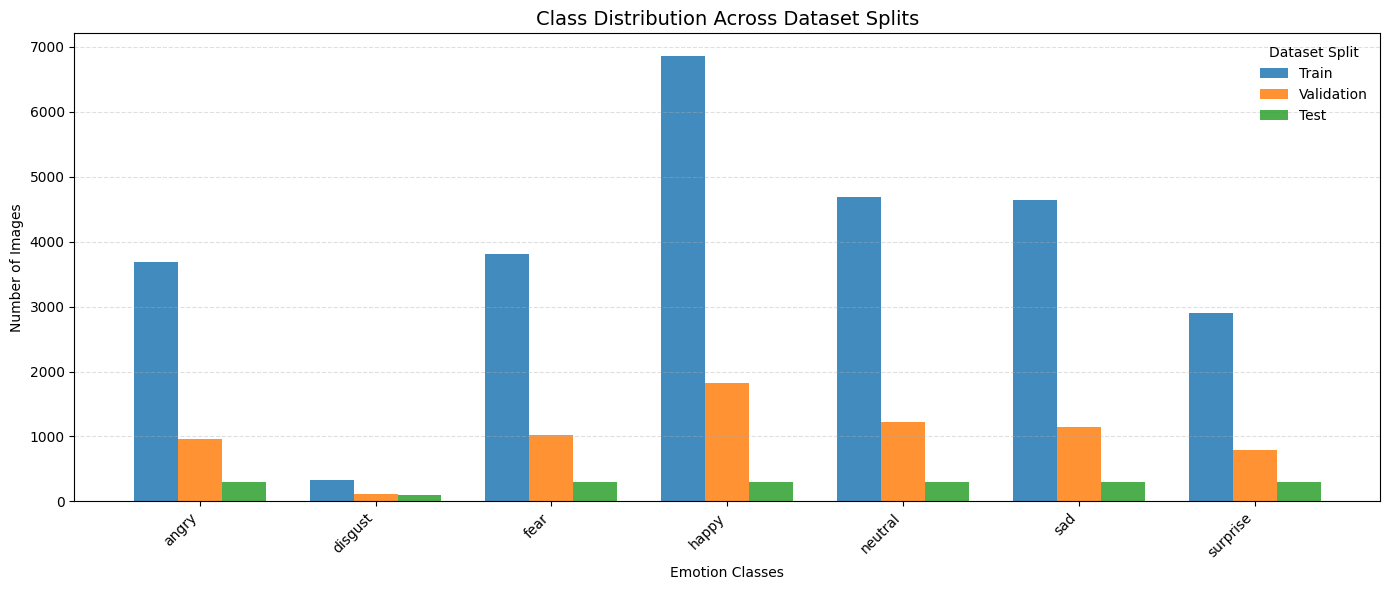

In [ ]:
# class distribution plot

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(14, 6))

# plot distribution for each dataset split
for i, split in enumerate(splits):
    values = [data_summary[split].get(cls, 0) for cls in classes]

    plt.bar(
        x + i * width,
        values,
        width,
        label=split.capitalize(),
        alpha=0.85
    )

plt.xticks(x + width, classes, rotation=45, ha="right")
plt.title("Class Distribution Across Dataset Splits", fontsize=14)
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")

plt.legend(title="Dataset Split", frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

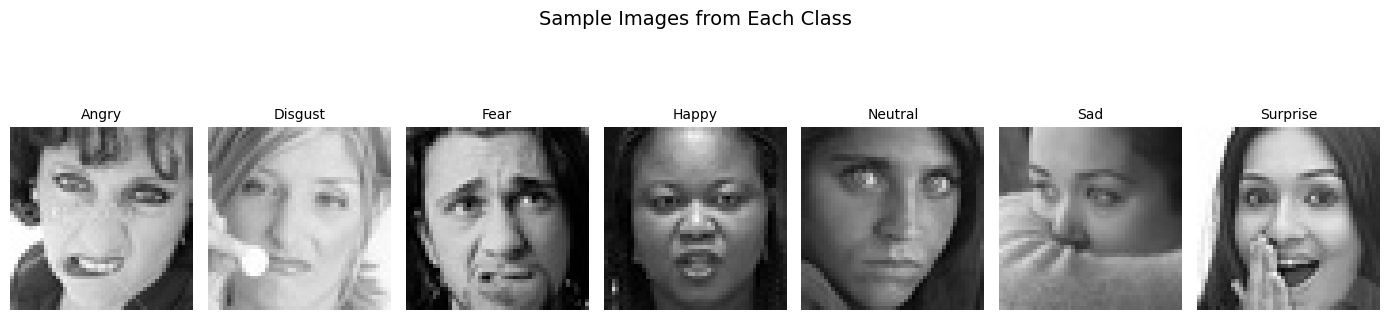

In [ ]:
# sample images visualization

plt.figure(figsize=(14, 4))

for i, cls in enumerate(classes[:7]):  # show up to 7 classes
    cls_path = os.path.join(train_path, cls)

    # get image files from class directory
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if not images:
        continue  # skip empty classes

    img_path = os.path.join(cls_path, images[0])  # take first image

    # read and convert image (BGR -> RGB)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 7, i + 1)
    plt.imshow(img)
    plt.title(cls.capitalize(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# corrupted image detection & cleaning

corrupted_files = []
total = 0
corrupted = 0

print("\nScanning for corrupted images...")

# traverse all files in dataset
for root, dirs, files in os.walk(working_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(root, file)
            total += 1

            try:
                # check image integrity
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                corrupted += 1
                corrupted_files.append(img_path)

                # remove corrupted image
                try:
                    os.remove(img_path)
                except Exception as e:
                    print(f"Error deleting {img_path}: {e}")

print("IMAGE CLEANING SUMMARY")
print(f"Total images scanned     : {total}")
print(f"Corrupted images removed : {corrupted}")
print(f"Sample removed files     : {corrupted_files[:5]}")


Scanning for corrupted images...
IMAGE CLEANING SUMMARY
Total images scanned     : 35887
Corrupted images removed : 49
Sample removed files     : ['/kaggle/working/working_dataset/train/fear/7955.jpg', '/kaggle/working/working_dataset/train/fear/10824.jpg', '/kaggle/working/working_dataset/train/fear/20859.jpg', '/kaggle/working/working_dataset/train/fear/28654.jpg', '/kaggle/working/working_dataset/train/fear/20295.jpg']


In [ ]:
# data augmentation setup

augmentation_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

# count original images per class (excluding augmented ones)
class_counts_original = {}

for cls in classes:
    cls_path = os.path.join(train_path, cls)

    class_counts_original[cls] = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
        and not f.startswith("aug_")
    ])

# compute target class size (slightly above median)
median_size = int(np.median(list(class_counts_original.values())))
target_size = int(median_size * 1.2)

print("Original class distribution:")
for cls, count in class_counts_original.items():
    print(f"  {cls}: {count}")

print(f"\nTarget size per class: {target_size}")


# augmentation process

for cls in classes:
    class_path = os.path.join(train_path, cls)

    original_images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
        and not f.startswith("aug_")
    ]

    current_count = len(original_images)

    if current_count == 0:
        continue

    # stronger augmentation for minority class
    if cls.lower() == "disgust":
        images_to_generate = target_size - current_count

        print(f"\n{cls}: {current_count} -> {target_size} (+{images_to_generate})")

        for _ in range(images_to_generate):
            img_path = os.path.join(class_path, random.choice(original_images))
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.reshape((1,) + img.shape)

            aug_iter = augmentation_datagen.flow(
                img,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix=f"aug_{cls}",
                save_format="jpg"
            )

            next(aug_iter)

    # light augmentation for other classes
    else:
        extra = int(0.1 * current_count)

        print(f"\n{cls}: {current_count} -> {current_count + extra} (+{extra})")

        for _ in range(extra):
            img_path = os.path.join(class_path, random.choice(original_images))
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.reshape((1,) + img.shape)

            aug_iter = augmentation_datagen.flow(
                img,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix=f"aug_{cls}",
                save_format="jpg"
            )

            next(aug_iter)

Original class distribution:
  angry: 3686
  disgust: 329
  fear: 3796
  happy: 6857
  neutral: 4675
  sad: 4631
  surprise: 2898

Target size per class: 4555

angry: 3686 -> 4054 (+368)

disgust: 329 -> 4555 (+4226)

fear: 3796 -> 4175 (+379)

happy: 6857 -> 7542 (+685)

neutral: 4675 -> 5142 (+467)

sad: 4631 -> 5094 (+463)

surprise: 2898 -> 3187 (+289)


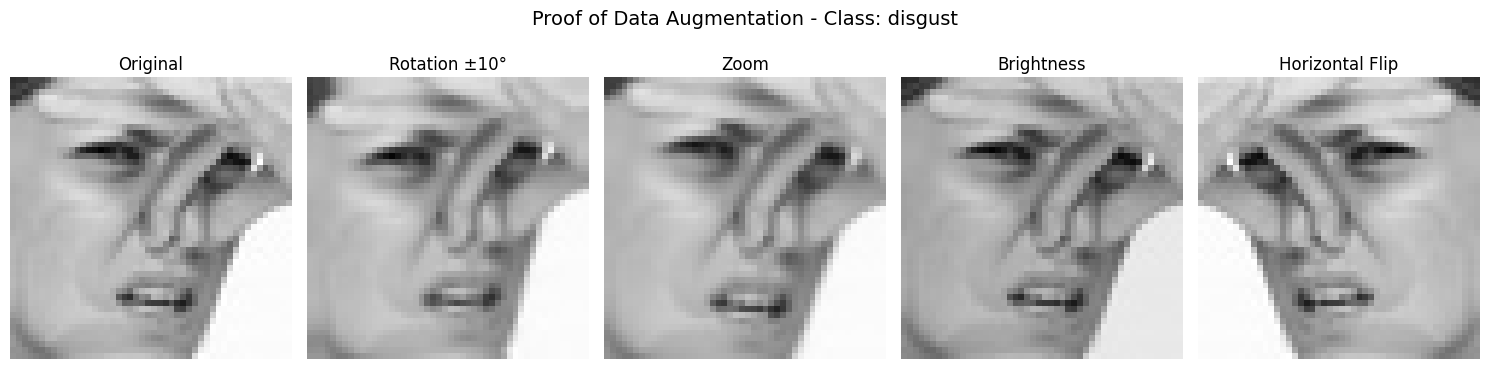

In [ ]:
# proof of data augmentation - visualization

sample_class = "disgust"
class_path = os.path.join(train_path, sample_class)

# select a random original (non-augmented) image
images = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

img_name = random.choice([f for f in images if not f.startswith("aug_")])
img_path = os.path.join(class_path, img_name)

# load image and prepare for augmentation
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.reshape((1,) + img.shape)


# apply individual augmentations

rot_gen = ImageDataGenerator(rotation_range=10)
zoom_gen = ImageDataGenerator(zoom_range=0.1)
bright_gen = ImageDataGenerator(brightness_range=[0.8, 1.2])
flip_gen = ImageDataGenerator(horizontal_flip=True)

rot_img = next(rot_gen.flow(img, batch_size=1))[0].astype("uint8")
zoom_img = next(zoom_gen.flow(img, batch_size=1))[0].astype("uint8")
bright_img = next(bright_gen.flow(img, batch_size=1))[0].astype("uint8")
flip_img = next(flip_gen.flow(img, batch_size=1))[0].astype("uint8")


# visualization

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

titles = ["Original", "Rotation ±10°", "Zoom", "Brightness", "Horizontal Flip"]
display_images = [
    img[0].astype("uint8"),
    rot_img,
    zoom_img,
    bright_img,
    flip_img
]

for ax, im, title in zip(axes, display_images, titles):
    ax.imshow(im)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.suptitle(f"Proof of Data Augmentation - Class: {sample_class}", fontsize=14)

plt.tight_layout()
plt.show()

FINAL CLASS DISTRIBUTION
angry: 4050 images
disgust: 3773 images
fear: 4170 images
happy: 7522 images
neutral: 5135 images
sad: 5090 images
surprise: 3182 images


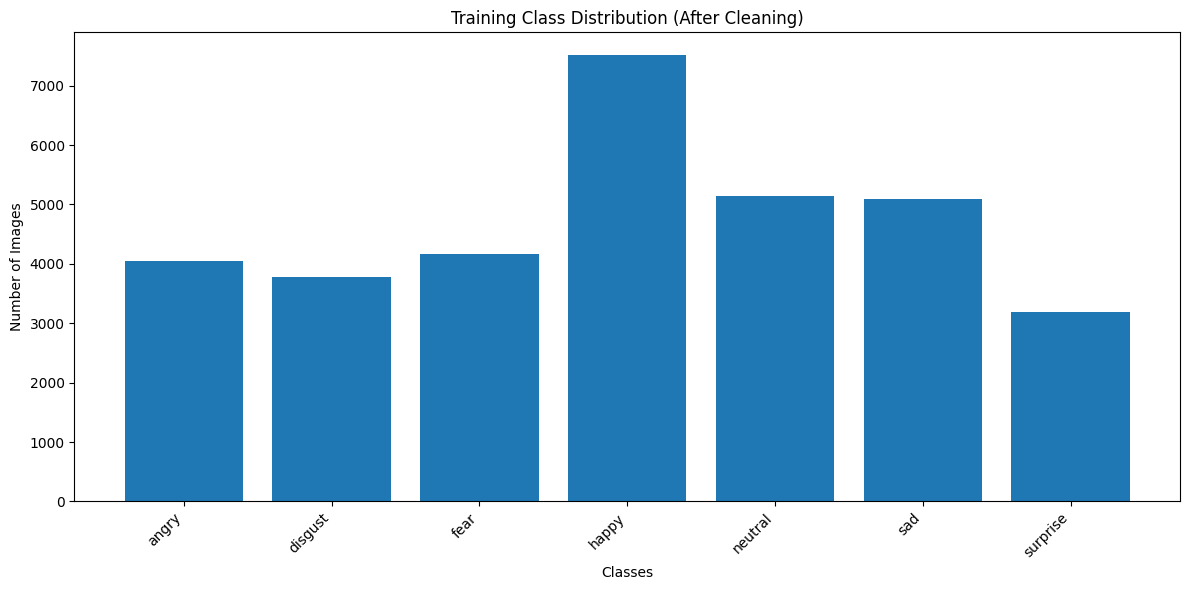

In [ ]:
# final distribution after cleaning

print("FINAL CLASS DISTRIBUTION")

final_counts = {}

for cls in classes:
    cls_path = os.path.join(train_path, cls)

    count = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    final_counts[cls] = count
    print(f"{cls}: {count} images")


# plot final distribution
plt.figure(figsize=(12, 6))

plt.bar(classes, [final_counts[cls] for cls in classes])

plt.title("Training Class Distribution (After Cleaning)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# data generators (resizing & normalization)

IMG_SIZE = 48
BATCH_SIZE = 32

# normalize pixel values to [0, 1]
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

print(f"\nClass labels: {class_labels}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 32922 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.

Class labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples: 32922
Validation samples: 7066
Test samples: 1900


In [ ]:
# class weights (handle data imbalance)

# extract class labels from training generator
y_train = train_generator.classes

# compute balanced class weights
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# map class indices to weights
class_weights = dict(zip(np.unique(y_train), class_weights_values))

print("Computed Class Weights:")
print(class_weights)

Computed Class Weights:
{np.int32(0): np.float64(1.1612698412698412), np.int32(1): np.float64(1.2465260686835031), np.int32(2): np.float64(1.127852004110997), np.int32(3): np.float64(0.6252516428001671), np.int32(4): np.float64(0.9158992905828349), np.int32(5): np.float64(0.9239966320516418), np.int32(6): np.float64(1.478046152464757)}


1. What does the dataset represent? Provide a brief description.
  
    The dataset represents human facial expressions categorized into seven distinct emotional states. Each image is a grayscale facial crop labeled with one of the following emotions: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise. It is designed for training computer vision models to recognize and classify human expressions.

2. How many total images are in the dataset?

   The dataset contains a total of 35,887 images, distributed across training, validation, and test sets. Training set: 26,921 images, Validation set: 7,066 images, Test set: 1,900 images


3. What is the distribution of images across different classes?

    The dataset shows an imbalance across classes. The training set distribution after analysis before cleaning is:

    Happy: 6867
    Neutral: 4682
    Sad: 4638
    Fear: 3803
    Angry: 3693
    Surprise: 2905
    Disgust: 336

    After augmentation, the distribution was improved, particularly increasing the minority class (Disgust), while maintaining natural variation in other classes.

4. How is the dataset split into training and validation sets? Justify your choice.

   The dataset is split into:

   75% Training
   20% Validation
   5% Testing

    This split ensures that the model has sufficient data for learning patterns while also maintaining unseen data for validation and final evaluation. The relatively smaller test set is used only for final performance estimation

5. What preprocessing techniques were applied?

    The following preprocessing steps were implemented:

    - Resizing: Images were resized to a uniform dimension (typically 48x48 or 224x224 depending on the model) to ensure consistent input shapes for the CNN.

    - Normalization: Pixel values were scaled (usually to a range of 0 to 1 or -1 to 1) to help the model converge faster during training.

    - Grayscale Conversion: Since facial expressions are often independent of color, images were processed in grayscale to reduce computational complexity.

6. What data generators were used for preprocessing and augmentation?

    The **ImageDataGenerator** class from TensorFlow/Keras was used for preprocessing, augmentation, and efficient batch loading during model training.

    The following augmentation techniques were applied to improve dataset diversity and reduce the effects of class imbalance, particularly for the underrepresented **Disgust** class:

      - **Horizontal Flipping** — generated mirrored versions of facial expressions.
      - **Rotation** — applied small angular rotations to simulate natural head tilts.
      - **Zooming** — slightly zoomed in/out to create scale variations.
      - **Brightness Adjustment** — varied image brightness to simulate different lighting conditions.

      These augmentations increased the variability of the training data while preserving the original facial expression labels.

# Design, Train, and Evaluate a Baseline Model:

### Model Architecture:

In [ ]:
# baseline cnn model

baseline_model = Sequential([
    # first convolution block
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # second convolution block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    # third convolution block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    # flatten feature maps to 1d vector
    Flatten(),

    # fully connected layers
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # output layer (multi-class classification)
    Dense(num_classes, activation="softmax")
])

# compile model
baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,399 (2.52 MB)

 Trainable params: 659,399 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training:

In [ ]:
# train baseline model

# callbacks for better training control

# stop training early if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# save best model during training
checkpoint = ModelCheckpoint(
    "baseline_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# track training time
start_time = time.time()

# model training
baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

# training duration in minutes
training_time = (time.time() - start_time) / 60
print(f"\nBASELINE MODEL Training Time: {training_time:.2f} minutes")

Epoch 1/30
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2921 - loss: 1.7895
Epoch 1: val_loss improved from inf to 1.47056, saving model to baseline_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.2921 - loss: 1.7894 - val_accuracy: 0.4404 - val_loss: 1.4706
Epoch 2/30
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4965 - loss: 1.3217
Epoch 2: val_loss improved from 1.47056 to 1.35429, saving model to baseline_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.4965 - loss: 1.3216 - val_accuracy: 0.4853 - val_loss: 1.3543
Epoch 3/30
1027/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5759 - loss: 1.1186
Epoch 3: val_loss improved from 1.35429 to 1.24253, saving model to baseline_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.5759 - loss: 1.1186 - val_accuracy: 0.5265 - val_loss: 1.2425
Epoch 4/30
1027/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6378 - loss: 0.9633
Epoch 4: val_loss imp

### Model Evaluation:

In [ ]:
# model evaluation function

def evaluate_model(model, history, test_generator, class_labels, model_name="Model"):
    """
    evaluates model performance:
    - training curves
    - test accuracy and loss
    - classification report
    - confusion matrix
    """

    # training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # loss curve
    ax1.plot(history.history["loss"], label="Training Loss")
    ax1.plot(history.history["val_loss"], label="Validation Loss")
    ax1.set_title(f"{model_name}: Loss Curve")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # accuracy curve
    ax2.plot(history.history["accuracy"], label="Training Accuracy")
    ax2.plot(history.history["val_accuracy"], label="Validation Accuracy")
    ax2.set_title(f"{model_name}: Accuracy Curve")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # test evaluation
    test_generator.reset()

    test_loss, test_acc = model.evaluate(test_generator, verbose=1)

    print("\n" + "=" * 50)
    print(f"{model_name.upper()} TEST PERFORMANCE")
    print("=" * 50)
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_acc * 100:.2f}%")

    # predictions
    y_pred_prob = model.predict(test_generator)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_generator.classes

    # classification report
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT")
    print("=" * 50)

    print(classification_report(y_true, y_pred, target_names=class_labels))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "val_acc": max(history.history["val_accuracy"])
    }

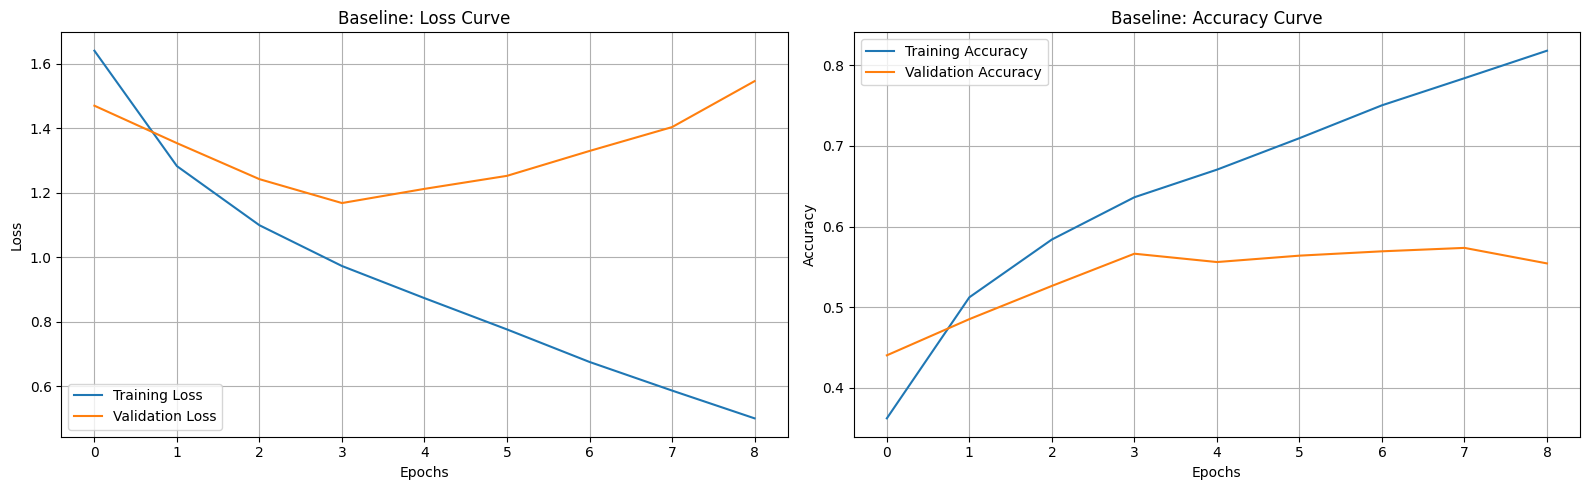

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4386 - loss: 1.4828

BASELINE TEST PERFORMANCE
Test Loss     : 1.3556
Test Accuracy : 50.00%
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.46      0.37      0.41       300
     disgust       0.64      0.38      0.48       100
        fear       0.40      0.26      0.31       300
       happy       0.54      0.80      0.65       300
     neutral       0.47      0.56      0.51       300
         sad       0.36      0.47      0.41       300
    surprise       0.82      0.58      0.68       300

    accuracy                           0.50      1900
   macro avg       0.53      0.49      0.49      1900
weighted avg       0.52      0.50      0.49      1900



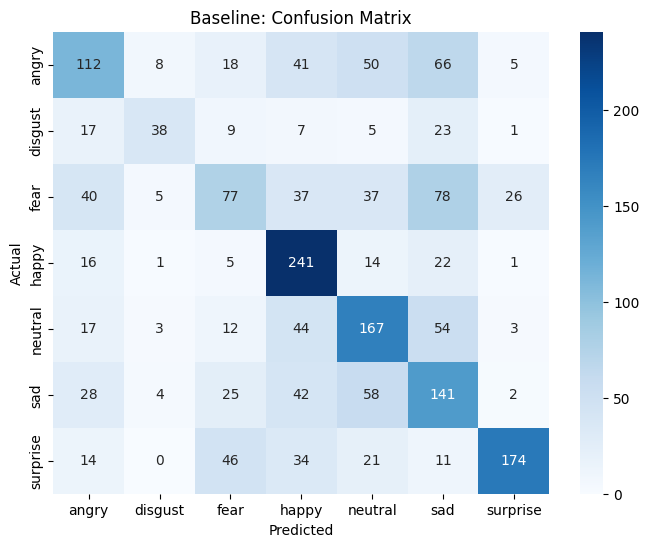

In [ ]:
baseline_results = evaluate_model(
    baseline_model,
    baseline_history,
    test_generator,
    class_labels,
    model_name="Baseline"
)

In [ ]:
# sample predictions visualization

def visualize_sample_predictions(model, test_generator, class_labels, img_size=48, n_samples=6, model_name="Model"):
    """
    visualizes random test images with predictions vs true labels
    """

    plt.figure(figsize=(15, 8))

    for i in range(n_samples):
        # pick random test image index
        idx = random.randint(0, len(test_generator.filepaths) - 1)
        img_path = test_generator.filepaths[idx]

        # load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # preprocess for model input
        img_resized = cv2.resize(img, (img_size, img_size))
        img_norm = img_resized / 255.0
        img_input = np.expand_dims(img_norm, axis=0)

        # model prediction
        pred = model.predict(img_input, verbose=0)
        pred_class = class_labels[np.argmax(pred)]

        # true label from folder name
        true_class = img_path.split("/")[-2]

        # plot image
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)

        color = "green" if pred_class == true_class else "red"
        plt.title(f"True: {true_class}\nPred: {pred_class}", color=color)
        plt.axis("off")

    plt.suptitle(f"{model_name}: Sample Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

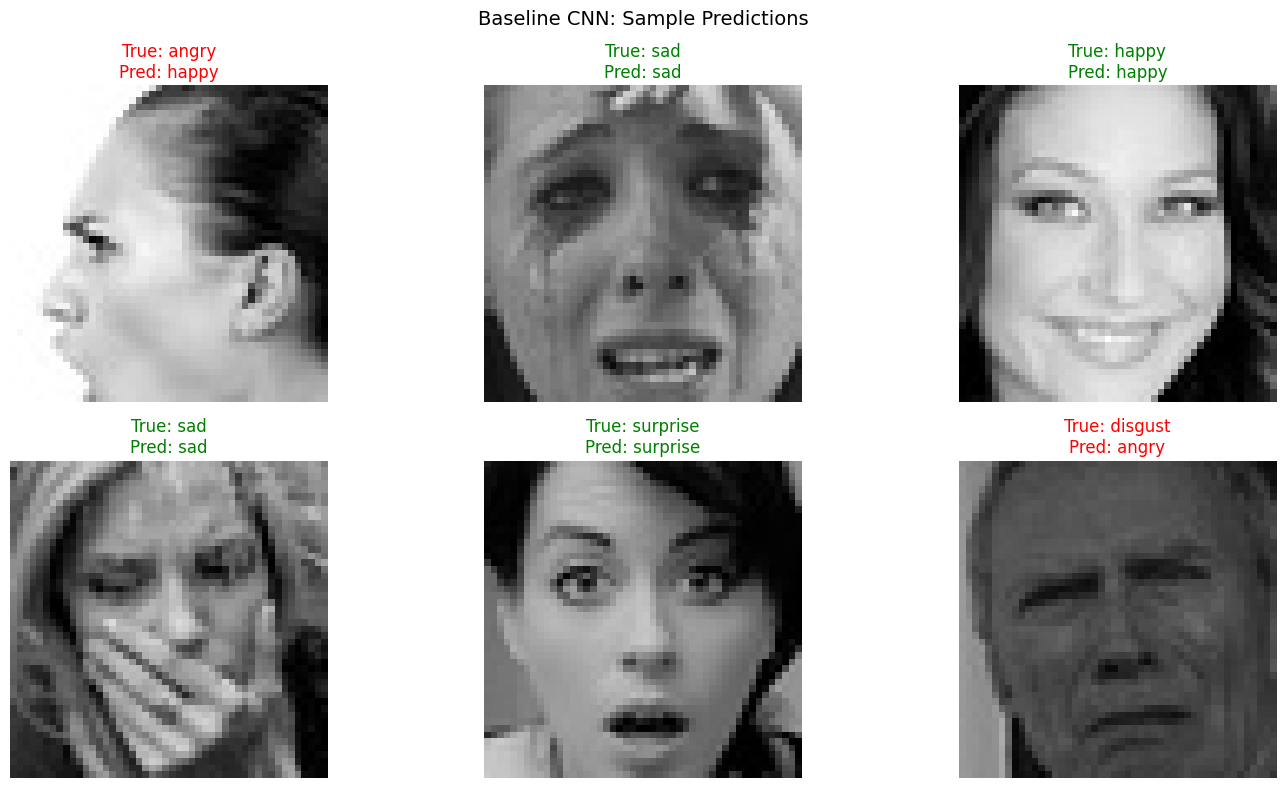

In [ ]:
visualize_sample_predictions(
    baseline_model,
    test_generator,
    class_labels,
    img_size=IMG_SIZE,
    n_samples=6,
    model_name="Baseline CNN"
)

### Key Observations on Baseline Model Performance

The baseline CNN model demonstrated steady learning during the initial training epochs. Training accuracy improved from approximately **29% in Epoch 1** to over **82% by Epoch 9**, indicating that the model was successfully learning discriminative facial features from the training data.

Validation accuracy increased consistently during the early epochs and reached its best performance of approximately **56.6%** at Epoch 4. After this point, validation loss began increasing while training accuracy continued improving, indicating the onset of **overfitting**. Early stopping restored the weights from the best-performing epoch to reduce further overfitting.

The model achieved a final **test accuracy of 50.00%**, which is acceptable for a simple baseline CNN trained from scratch on a challenging facial emotion recognition dataset.

Several class-level performance differences were observed:

- **Happy** and **Surprise** achieved the highest performance scores. These expressions contain stronger and more visually distinctive facial patterns, making them easier for the CNN to classify.
- **Fear**, **Sad**, and **Angry** showed comparatively lower recall and F1-scores. These emotions share overlapping facial characteristics, leading to increased misclassification.
- The **Disgust** class achieved moderate performance despite severe class imbalance, suggesting that data augmentation and class weighting partially improved minority-class learning.

The architecture contained approximately **659K trainable parameters**, making it lightweight and computationally efficient. Training completed in approximately **2.8 minutes**, demonstrating fast convergence and low computational cost.

Overall, the baseline model established a strong reference point for later experiments involving deeper CNN architectures and transfer learning approaches.

### Deeper Architecture with Regularization Layer:

### Model Architecture:

In [ ]:
# deeper cnn model with regularization
deeper_model = Sequential([

    # block 1
    Conv2D(64, (3,3), activation="relu", padding="same", input_shape=(48,48,3)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    # block 2
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    # block 3
    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    # block 4
    Conv2D(512, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    GlobalAveragePooling2D(),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

# compile model
deeper_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             

 Total params: 1,984,647 (7.57 MB)

 Trainable params: 1,981,703 (7.56 MB)

 Non-trainable params: 2,944 (11.50 KB)

### Model Training: ADAM

In [ ]:
# train deeper model with adam optimizer

# save best model based on validation loss
checkpoint_adam = ModelCheckpoint(
    "deeper_model_adam_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# track training time
start_time = time.time()

# model training
history_adam = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_adam]
)

# training duration in minutes
training_time_adam = (time.time() - start_time) / 60

print(f"DEEPER MODEL (ADAM) Training Time: {training_time_adam:.2f} minutes")

Epoch 1/30
1026/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1685 - loss: 2.1281
Epoch 1: val_loss improved from inf to 3.95953, saving model to deeper_model_adam_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.1686 - loss: 2.1275 - val_accuracy: 0.0270 - val_loss: 3.9595
Epoch 2/30
1028/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2574 - loss: 1.7815
Epoch 2: val_loss improved from 3.95953 to 2.52818, saving model to deeper_model_adam_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.2574 - loss: 1.7814 - val_accuracy: 0.1186 - val_loss: 2.5282
Epoch 3/30
1027/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3493 - loss: 1.6171
Epoch 3: val_loss improved from 2.52818 to 1.91184, saving model to deeper_model_adam_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3493 - loss: 1.6170 - val_accuracy: 0.2738 - val_loss: 1.9118
Epoch 4/30
1028/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4364 - loss: 1

### Model Training: SGD

In [ ]:
# train deeper model with sgd optimizer

# clone the already defined deeper model architecture
sgd_model = tf.keras.models.clone_model(deeper_model)

# compile with sgd optimizer
sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# save best model based on validation loss
checkpoint_sgd = ModelCheckpoint(
    "deeper_model_sgd_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# track training time
start_time = time.time()

# model training
history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_sgd]
)

# compute training duration in minutes
training_time_sgd = (time.time() - start_time) / 60

print(f"DEEPER MODEL (SGD) Training Time: {training_time_sgd:.2f} minutes")

Epoch 1/30
1028/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1640 - loss: 2.0589
Epoch 1: val_loss improved from inf to 1.90294, saving model to deeper_model_sgd_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.1640 - loss: 2.0587 - val_accuracy: 0.1664 - val_loss: 1.9029
Epoch 2/30
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1688 - loss: 1.9275
Epoch 2: val_loss improved from 1.90294 to 1.89134, saving model to deeper_model_sgd_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.1688 - loss: 1.9275 - val_accuracy: 0.2615 - val_loss: 1.8913
Epoch 3/30
1026/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2024 - loss: 1.9129
Epoch 3: val_loss improved from 1.89134 to 1.88433, saving model to deeper_model_sgd_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.2024 - loss: 1.9129 - val_accuracy: 0.1987 - val_loss: 1.8843
Epoch 4/30
1027/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1904 - loss: 1.91

### Model Evaluation:

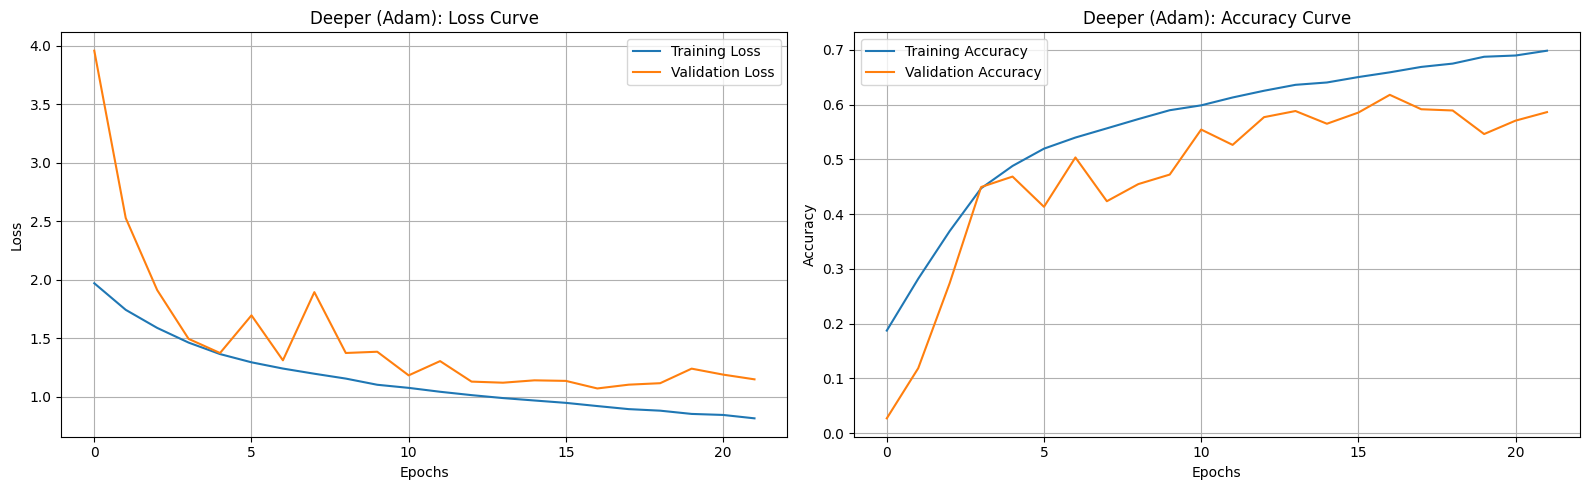

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4753 - loss: 1.5029

DEEPER (ADAM) TEST PERFORMANCE
Test Loss     : 1.2756
Test Accuracy : 55.89%
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.55      0.41      0.47       300
     disgust       0.79      0.50      0.61       100
        fear       0.55      0.25      0.35       300
       happy       0.67      0.80      0.73       300
     neutral       0.42      0.72      0.53       300
         sad       0.41      0.41      0.41       300
    surprise       0.78      0.77      0.78       300

    accuracy                           0.56      1900
   macro avg       0.60      0.55      0.55      1900
weighted avg       0.58      0.56      0.55      1900



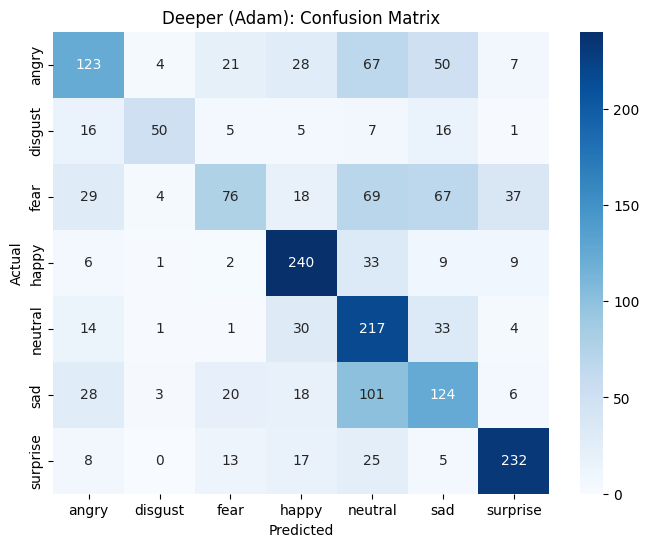

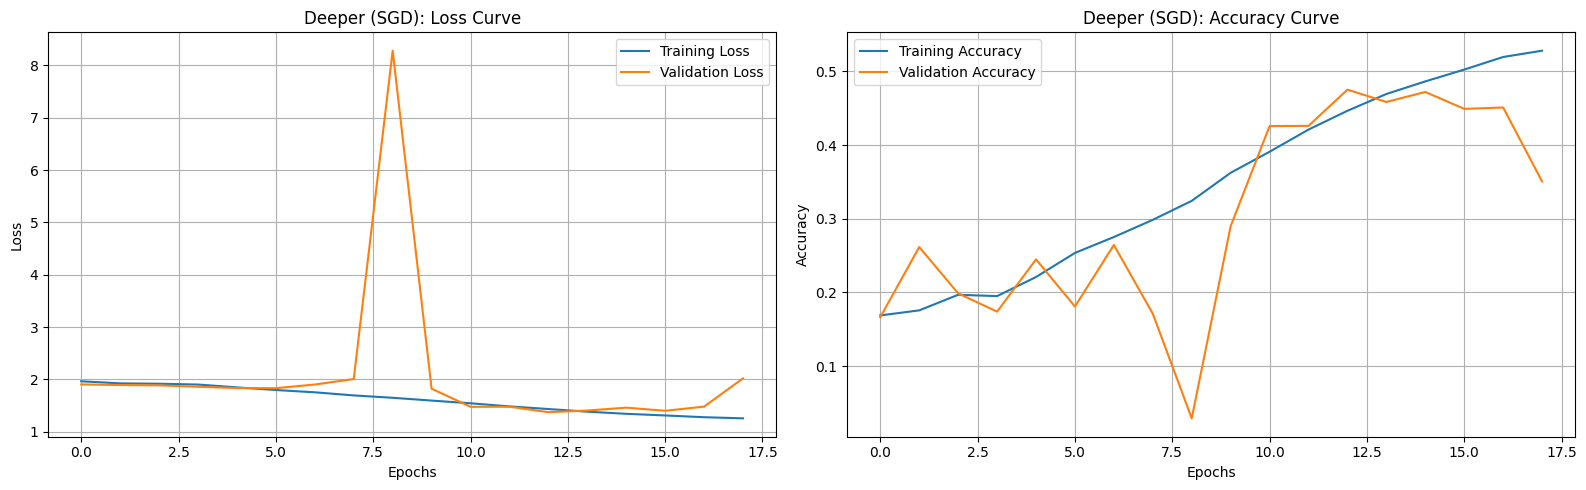

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2583 - loss: 1.8137

DEEPER (SGD) TEST PERFORMANCE
Test Loss     : 1.5504
Test Accuracy : 40.47%
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.50      0.13      0.21       300
     disgust       0.29      0.10      0.15       100
        fear       0.22      0.11      0.15       300
       happy       0.44      0.78      0.56       300
     neutral       0.37      0.48      0.42       300
         sad       0.28      0.39      0.32       300
    surprise       0.67      0.64      0.65       300

    accuracy                           0.40      1900
   macro avg       0.39      0.38      0.35      1900
weighted avg       0.41      0.40      0.37      1900



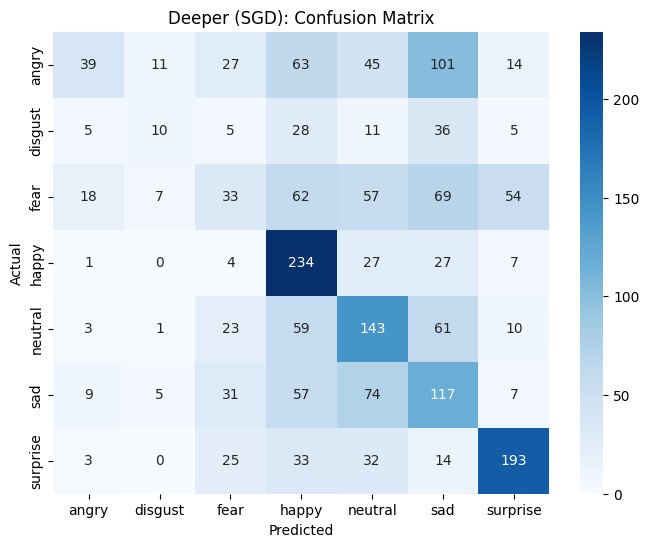

In [ ]:
# deeper model (adam) evaluation

adam_results = evaluate_model(
    deeper_model,
    history_adam,
    test_generator,
    class_labels,
    model_name="Deeper (Adam)"
)

# deeper model (sgd) evaluation

sgd_results = evaluate_model(
    sgd_model,
    history_sgd,
    test_generator,
    class_labels,
    model_name="Deeper (SGD)"
)


DEEPER MODEL (ADAM) - SAMPLE PREDICTIONS


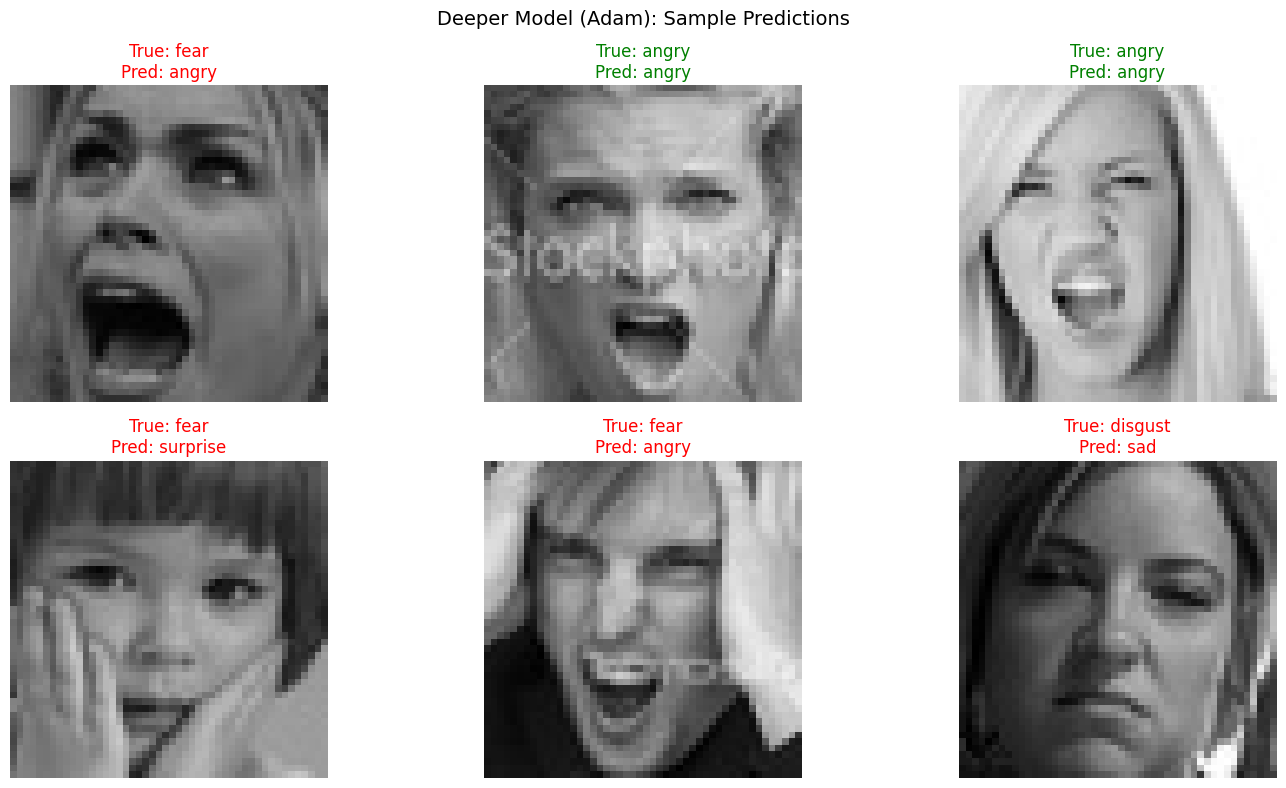


DEEPER MODEL (SGD) - SAMPLE PREDICTIONS


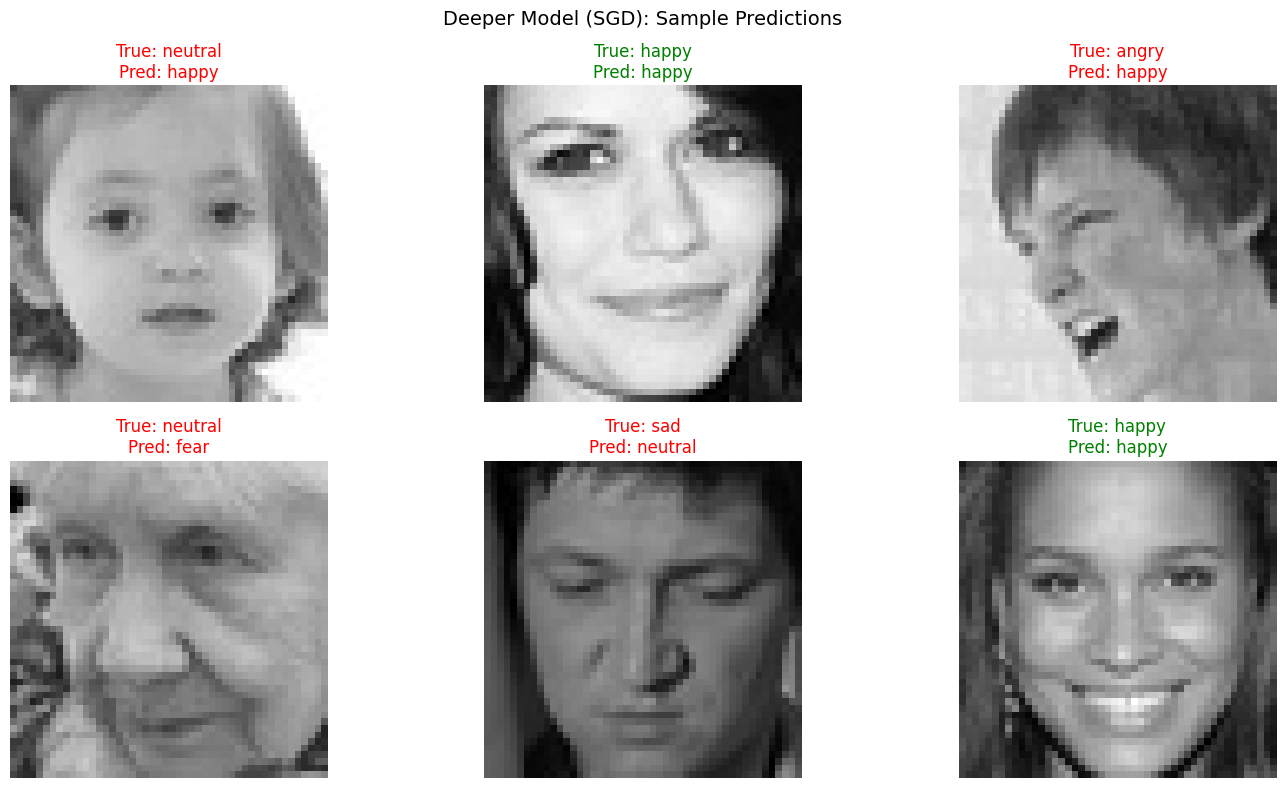

In [ ]:
print("\n" + "="*60)
print("DEEPER MODEL (ADAM) - SAMPLE PREDICTIONS")
print("="*60)

visualize_sample_predictions(
    model=deeper_model,
    test_generator=test_generator,
    class_labels=class_labels,
    img_size=48,
    n_samples=6,
    model_name="Deeper Model (Adam)"
)

print("\n" + "="*60)
print("DEEPER MODEL (SGD) - SAMPLE PREDICTIONS")
print("="*60)

visualize_sample_predictions(
    model=sgd_model,
    test_generator=test_generator,
    class_labels=class_labels,
    img_size=48,
    n_samples=6,
    model_name="Deeper Model (SGD)"
)

### Experimentation and Comparative Analysis:

In [ ]:
# baseline vs deeper model performance

summary_df = pd.DataFrame({
    "Model": ["Baseline", "Deeper (Adam)", "Deeper (SGD)"],

    # best validation accuracy from evaluation results
    "Best Val Accuracy (%)": [
        baseline_results["val_acc"] * 100,
        adam_results["val_acc"] * 100,
        sgd_results["val_acc"] * 100
    ],

    # test accuracy from evaluation results
    "Test Accuracy (%)": [
        baseline_results["test_acc"] * 100,
        adam_results["test_acc"] * 100,
        sgd_results["test_acc"] * 100
    ],

    # training time comparison
    "Training Time (min)": [
        training_time,
        training_time_adam,
        training_time_sgd
    ],

    # approximate parameter counts
    "Parameters": ["~366K", "~498K", "~498K"]
})

print(summary_df.to_string(index=False))

        Model  Best Val Accuracy (%)  Test Accuracy (%)  Training Time (min) Parameters
     Baseline              57.359183          50.000000             2.799280      ~366K
Deeper (Adam)              61.788845          55.894738             7.370867      ~498K
 Deeper (SGD)              47.509199          40.473685             6.018457      ~498K


### BASELINE VS DEEPER MODEL PERFORMANCE

  The deeper CNN model improved performance compared to the baseline CNN model.

* Baseline CNN:
  * Validation Accuracy : 57.36%
  * Test Accuracy       : 50.00%
  * Training Time       : 2.80 minutes

* Deeper CNN (Adam):
  * Validation Accuracy : 61.79%
  * Test Accuracy       : 55.89%
  * Training Time       : 7.37 minutes

Adding more convolutional layers, filters, Batch Normalization, Dropout, and Global Average Pooling helped the deeper model learn richer facial features and improve classification performance.

The deeper model performed better on most emotion classes such as happy, neutral, and surprise.

However, increased model complexity led to higher training time and computational cost compared to the baseline model.

Both models showed mild overfitting, handled using early stopping.




### OPTIMIZER ANALYSIS: SGD VS ADAM

The deeper CNN model was trained using Adam and SGD optimizers.

* Adam Optimizer:
  * Validation Accuracy : 61.79%
  * Test Accuracy       : 55.89%
  * Training Time       : 7.37 minutes

* SGD Optimizer:
  * Validation Accuracy : 47.51%
  * Test Accuracy       : 40.47%
  * Training Time       : 6.02 minutes

Adam showed much better convergence and stability than SGD. SGD struggled with learning deeper representations and showed unstable validation performance.

Overall, Adam clearly outperformed SGD in both accuracy and generalization, despite slightly longer training time.

In [ ]:
# ablation study
# (removing batch normalization only)

ablation_model = Sequential([

    # block 1
    Conv2D(64, (3,3), activation="relu", padding="same",
           input_shape=(48,48,3)),
    MaxPooling2D(),
    Dropout(0.25),

    # block 2
    Conv2D(128, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.25),

    # block 3
    Conv2D(256, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.25),

    # block 4
    Conv2D(512, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.25),

    GlobalAveragePooling2D(),

    # classifier head
    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

# compile
ablation_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# checkpoint
checkpoint_ablation = ModelCheckpoint(
    "ablation_model_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# training
print("Training Ablation Model (No Batch Normalization)")

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_ablation],
    verbose=1
)

# evaluation print
print("\n" + "=" * 50)
print("ABLATION STUDY RESULTS")
print("=" * 50)

print(f"Original Deeper Model (Adam) - Val Acc: {adam_results['val_acc'] * 100:.2f}%")
print(f"Ablation Model (No BN)       - Val Acc: {max(history_ablation.history['val_accuracy']) * 100:.2f}%")

Training Ablation Model (No Batch Normalization)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1026/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1384 - loss: 1.9494
Epoch 1: val_loss improved from inf to 1.94318, saving model to ablation_model_best.keras
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.1384 - loss: 1.9494 - val_accuracy: 0.1359 - val_loss: 1.9432
Epoch 2/30
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1407 - loss: 1.9448
Epoch 2: val_loss did not improve from 1.94318
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.1407 - loss: 1.9448 - val_accuracy: 0.0157 - val_loss: 1.9525
Epoch 3/30
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1189 - loss: 1.9443
Epoch 3: val_loss did not improve from 1.94318
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.1189 - loss: 1.9443 - val_accuracy: 0.1612 - val_loss: 1.9482
Epoch 4/30
1026/1029 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1401 - loss: 1.9497
Epoch 4: val_loss did not improve from 1.94318
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.14

### ANALYSIS: PERFORMANCE CHANGE (ABLATION STUDY)

Removing Batch Normalization caused a severe drop in performance.

* With Batch Normalization (Deeper Adam model):
  * Validation Accuracy : 61.79%
  * Stable convergence and consistent improvement across epochs

* Without Batch Normalization (Ablation model):
  * Validation Accuracy : ~16%
  * Training Accuracy   : ~13–15%
  * Loss remained almost constant (~1.94–1.95)

Key observations:
  * The model failed to learn meaningful features without Batch Normalization.
  * Training became unstable, with little to no improvement across epochs.
  * Validation performance collapsed close to random guessing level.


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

### Loading and Adapting a Pre - Trained Model:

In [ ]:
# transfer learning setup (resnet50 input size)

IMG_SIZE_TL = 224
BATCH_SIZE_TL = 32

# data generators (using resnet preprocessing)
train_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE_TL,
    class_mode="categorical"
)

val_generator_tl = val_datagen_tl.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE_TL,
    class_mode="categorical"
)

test_generator_tl = test_datagen_tl.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE_TL,
    class_mode="categorical",
    shuffle=False
)

# pretrained model (resnet50 backbone)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3)
)

# freeze base model layers
base_model.trainable = False

Found 32883 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


In [ ]:
# transfer learning model (resnet50 + custom head)

transfer_model = Sequential([
    base_model,

    # convert feature maps to vector
    GlobalAveragePooling2D(),

    # classifier head
    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # output layer
    Dense(num_classes, activation="softmax")
])

transfer_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,055 (92.11 MB)

 Trainable params: 18,627,591 (71.06 MB)

 Non-trainable params: 5,518,464 (21.05 MB)

In [ ]:
# callbacks for transfer learning model

# stop training early if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# save best performing model
checkpoint = ModelCheckpoint(
    "transfer_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# reduce learning rate when model plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

### Model Training: Feature Extraction

In [ ]:
# compile transfer learning model

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# start fine-tuning timer
start_fe = time.time()

# train model
history_fe = transfer_model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# compute training time in minutes
fe_time = (time.time() - start_fe) / 60
print("FE Training Time (min):", fe_time)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1028/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2544 - loss: 2.5100
Epoch 1: val_loss improved from inf to 2.03994, saving model to transfer_best.keras
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 89s 73ms/step - accuracy: 0.2544 - loss: 2.5098 - val_accuracy: 0.4222 - val_loss: 2.0399 - learning_rate: 1.0000e-04
Epoch 2/30
1027/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3959 - loss: 2.0067
Epoch 2: val_loss improved from 2.03994 to 1.84275, saving model to transfer_best.keras
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step - accuracy: 0.3960 - loss: 2.0066 - val_accuracy: 0.4556 - val_loss: 1.8428 - learning_rate: 1.0000e-04
Epoch 3/30
1027/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4454 - loss: 1.8356
Epoch 3: val_loss improved from 1.84275 to 1.72681, saving model to transfer_best.keras
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 63s 61ms/step - accuracy: 0.4454 - loss: 1.8355 - val_accuracy: 0.4810 - val_loss: 1.7268 - learning_rate: 1.0000e-04
Epoch 4/30
1027/1028 ━━━━━━━━━━━━━━━━

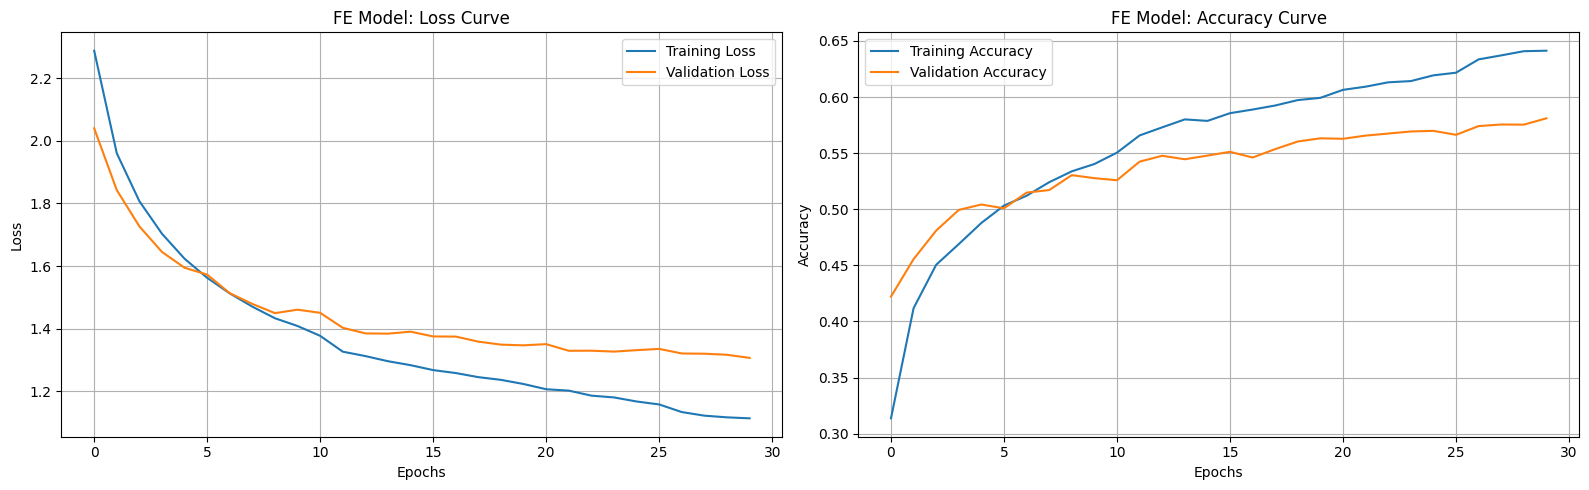

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.4807 - loss: 1.5778

FE MODEL TEST PERFORMANCE
Test Loss     : 1.4453
Test Accuracy : 52.89%
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.45      0.49      0.47       300
     disgust       0.82      0.27      0.41       100
        fear       0.46      0.29      0.36       300
       happy       0.64      0.77      0.70       300
     neutral       0.46      0.57      0.51       300
         sad       0.40      0.42      0.41       300
    surprise       0.71      0.71      0.71       300

    accuracy                           0.53      1900
   macro avg       0.56      0.50      0.51      1900
weighted avg       0.54      0.53      0.52      1900



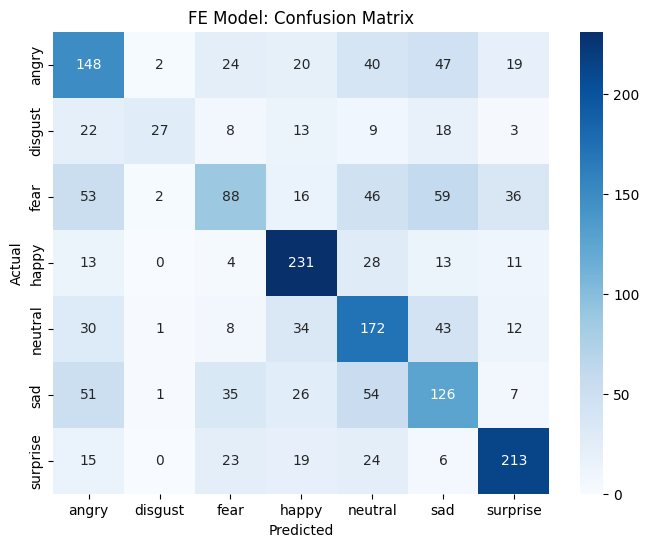

In [ ]:
fe_results = evaluate_model(
    transfer_model,
    history_fe,
    test_generator_tl,
    class_labels,
    model_name="FE Model"
)

### Model Training: Fine Tuning

In [ ]:
# unfreeze base model for fine-tuning

base_model.trainable = True

# freeze early layers, train deeper layers only
for layer in base_model.layers[:-140]:
    layer.trainable = False

In [ ]:
# compile model for fine-tuning

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# callbacks for fine-tuning

early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_ft = ModelCheckpoint(
    "transfer_ft_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# start fine-tuning timer
start_ft = time.time()

# fine-tune model
history_ft = transfer_model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop_ft, checkpoint_ft],
    verbose=1
)

# compute fine-tuning time in minutes
ft_time = (time.time() - start_ft) / 60
print("FT Training Time (min):", ft_time)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1028/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7378 - loss: 1.3218
Epoch 1: val_loss improved from inf to 1.66328, saving model to transfer_ft_best.keras
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 144s 114ms/step - accuracy: 0.7378 - loss: 1.3218 - val_accuracy: 0.6380 - val_loss: 1.6633
Epoch 2/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8012 - loss: 1.1397
Epoch 2: val_loss did not improve from 1.66328
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 98s 96ms/step - accuracy: 0.8012 - loss: 1.1397 - val_accuracy: 0.6344 - val_loss: 1.7426
Epoch 3/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8624 - loss: 0.9740
Epoch 3: val_loss did not improve from 1.66328
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 98s 96ms/step - accuracy: 0.8624 - loss: 0.9740 - val_accuracy: 0.6330 - val_loss: 1.8305
Epoch 4/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9110 - loss: 0.8391
Epoch 4: val_loss did not improve from 1.66328
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 98s 96ms/step - accuracy: 0.910

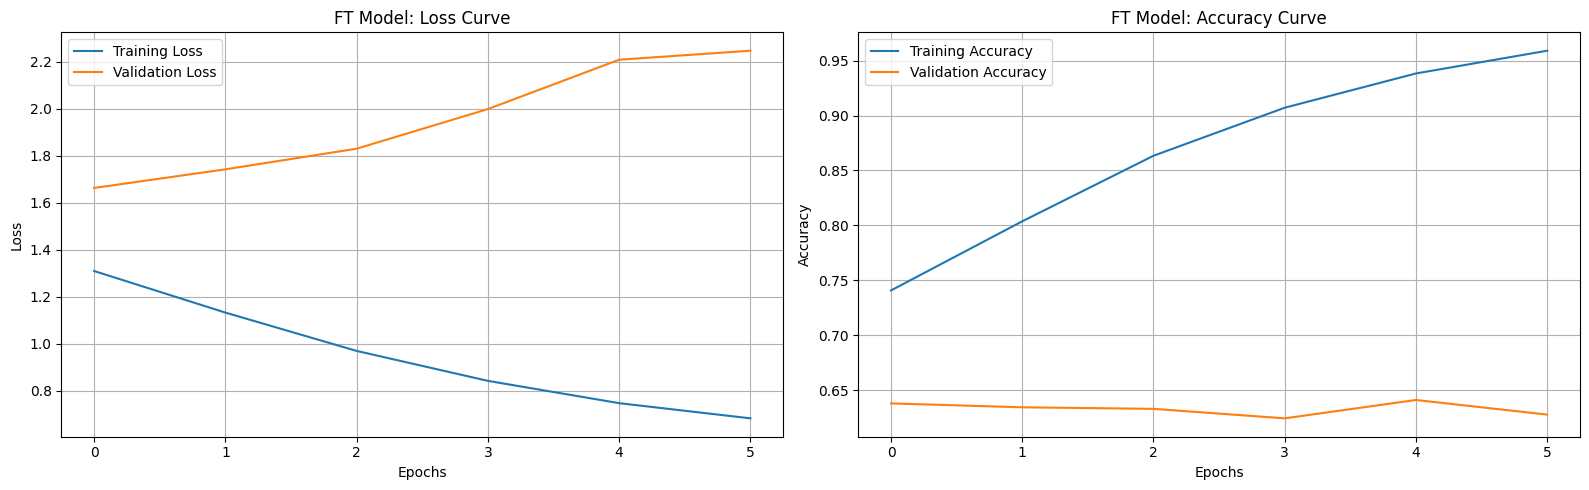

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.5405 - loss: 1.9185

FT MODEL TEST PERFORMANCE
Test Loss     : 1.7786
Test Accuracy : 59.26%
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.48      0.54      0.51       300
     disgust       0.77      0.43      0.55       100
        fear       0.48      0.39      0.43       300
       happy       0.75      0.83      0.79       300
     neutral       0.59      0.59      0.59       300
         sad       0.43      0.50      0.46       300
    surprise       0.81      0.76      0.78       300

    accuracy                           0.59      1900
   macro avg       0.62      0.58      0.59      1900
weighted avg       0.60      0.59      0.59      1900



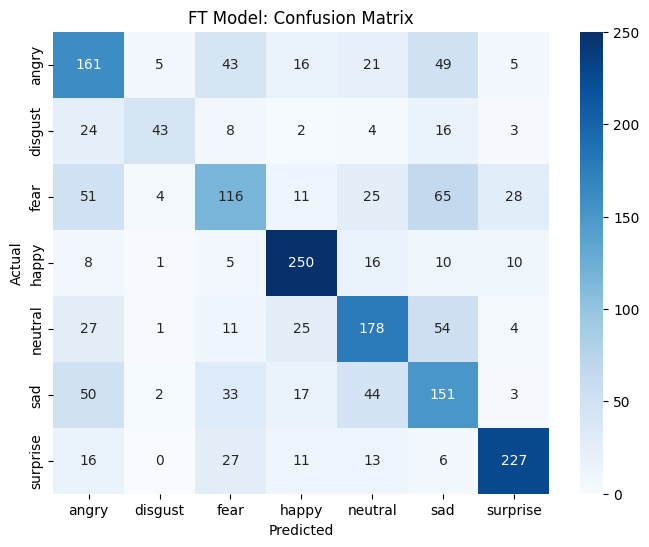

In [ ]:
ft_results = evaluate_model(
    transfer_model,
    history_ft,
    test_generator_tl,
    class_labels,
    model_name="FT Model"
)


TRANSFER LEARNING (FE) - SAMPLE PREDICTIONS


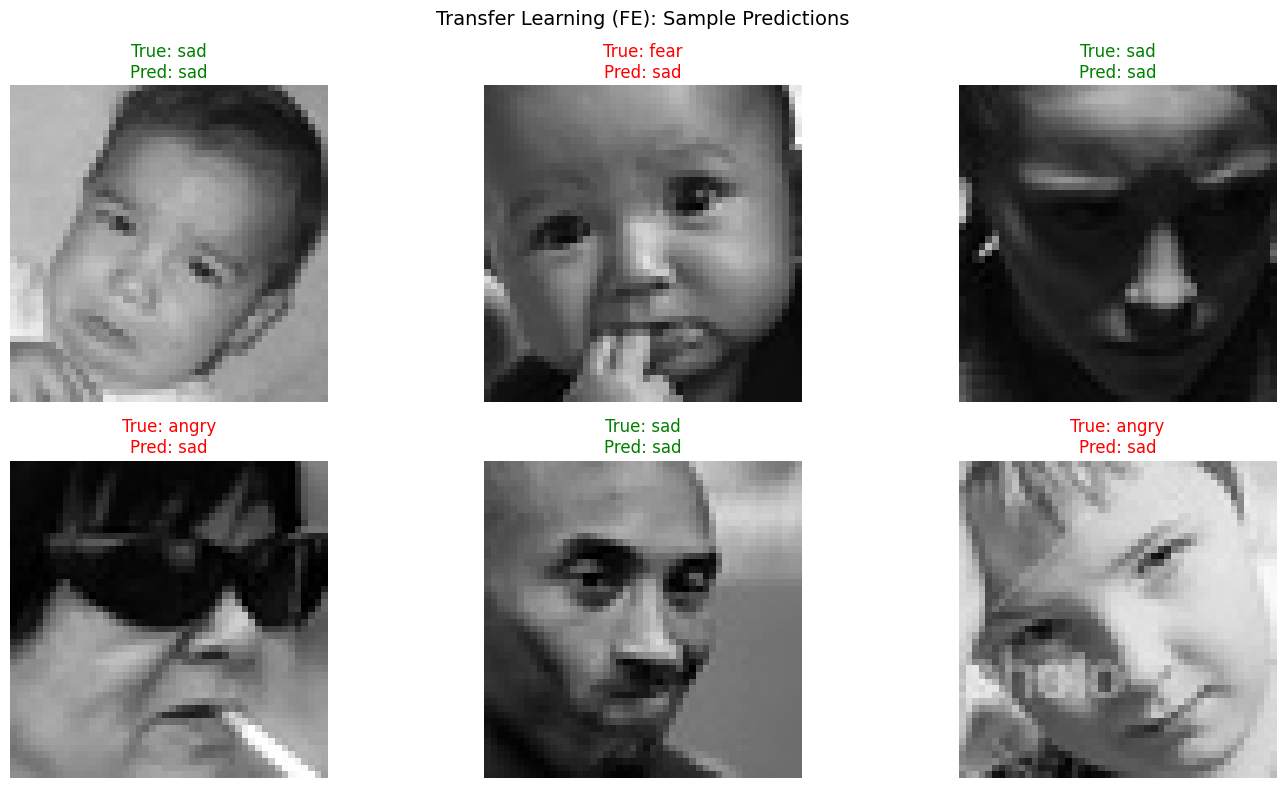


TRANSFER LEARNING (FT) - SAMPLE PREDICTIONS


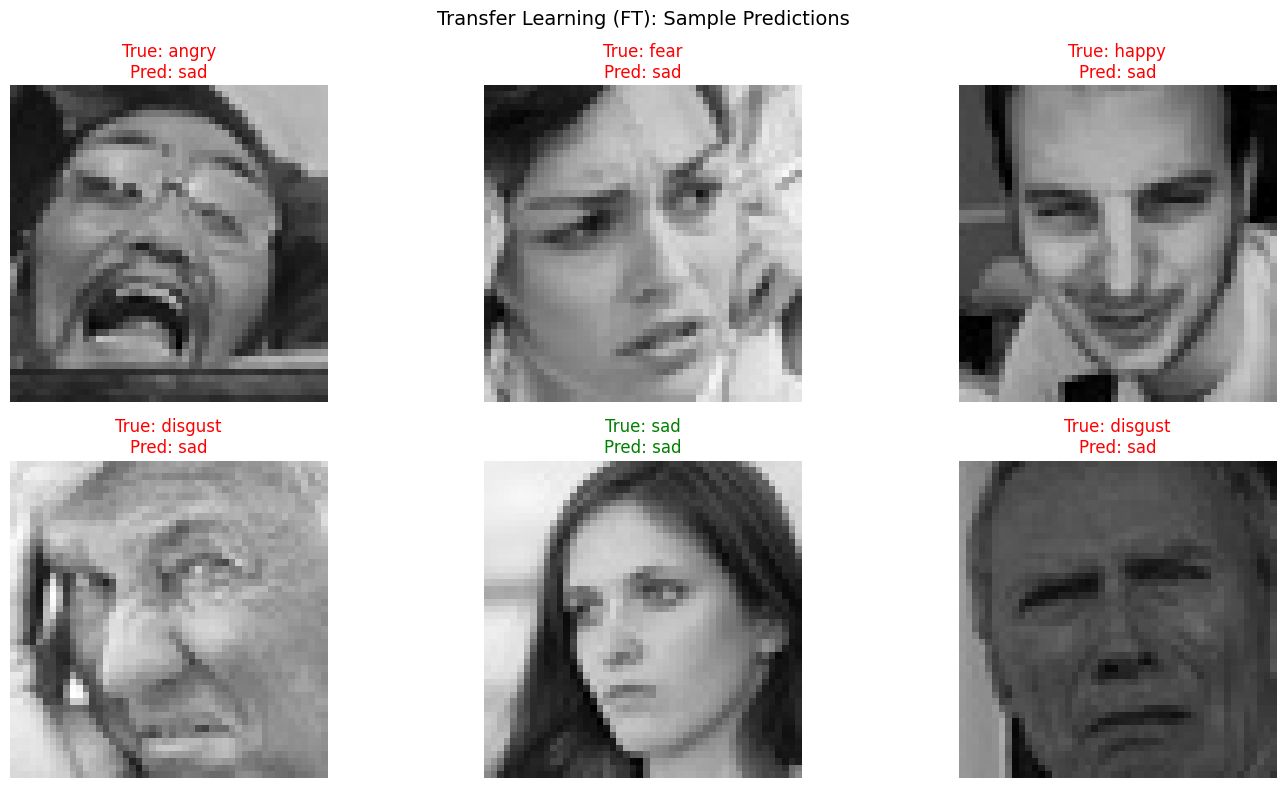

In [ ]:
print("\n" + "="*60)
print("TRANSFER LEARNING (FE) - SAMPLE PREDICTIONS")
print("="*60)

visualize_sample_predictions(
    transfer_model_fe,
    test_generator_tl,
    class_labels,
    img_size=224,
    n_samples=6,
    model_name="Transfer Learning (FE)"
)

print("\n" + "="*60)
print("TRANSFER LEARNING (FT) - SAMPLE PREDICTIONS")
print("="*60)

visualize_sample_predictions(
    transfer_model_ft,
    test_generator_tl,
    class_labels,
    img_size=224,
    n_samples=6,
    model_name="Transfer Learning (FT)"
)

Transfer learning performs better than training from scratch.

- **Scratch model:** ~50% test accuracy, unstable learning, overfitting early

- **Transfer learning:** ~59% test accuracy, smoother and more stable training

**Why it performed better:** It uses pretrained features (edges, textures, facial structures) learned from large datasets so it needs less data to learn good representations.It converges faster and avoids overfitting compared to random weight initialization. Overall, transfer learning works better because it starts with useful visual knowledge instead of learning everything from zero.

### Challenges and Observations

The main challenge was the dataset size, which contained a large number of images. Training on the standard Google Colab environment was too slow, so the project was moved to Kaggle using a GPU (P100) for faster computation.
Even with hardware acceleration, training time remained high, especially for deeper models. The full transfer learning model took approximately ~32 minutes, while fine-tuning took ~10 minutes on GPU.

Despite multiple experiments (data augmentation, adding/removing layers, and tuning learning rates), model performance remained limited, with most architectures plateauing in the 50–60% accuracy range.

Overfitting was observed in the scratch CNN model, where training accuracy increased but validation performance stopped improving early.
Transfer learning reduced overfitting but still showed a performance ceiling, suggesting dataset complexity and class overlap were major limiting factors.

Overall, the biggest difficulty was improving accuracy beyond a stable plateau, even after extensive tuning and architectural changes.